# Exploratory Data Analysis (EDA)

In [1]:
# Importing necessary libraries
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm # for progress bar

In [2]:
# Configurations
DATA_ROOT = Path('../data/raw/messy_mashup/')
GENRES_PATH = DATA_ROOT / "genres_stems"
ESC50_PATH = DATA_ROOT / "ESC-50-master"
MASHUPS_PATH = DATA_ROOT / "mashups"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [3]:
# Checking the dataset structure
def validate_dataset_structure():
    print("Root Contents:", list(DATA_ROOT.iterdir()))
    print("Genres Contents:", list(GENRES_PATH.iterdir()))
    print("ESC-50 Contents:", list(ESC50_PATH.iterdir()))
    print("Mashups Count:", len(list(MASHUPS_PATH.glob("*.wav"))))

validate_dataset_structure()

Root Contents: [PosixPath('../data/raw/messy_mashup/genres_stems'), PosixPath('../data/raw/messy_mashup/test.csv'), PosixPath('../data/raw/messy_mashup/ESC-50-master'), PosixPath('../data/raw/messy_mashup/sample_submission.csv'), PosixPath('../data/raw/messy_mashup/mashups')]
Genres Contents: [PosixPath('../data/raw/messy_mashup/genres_stems/country'), PosixPath('../data/raw/messy_mashup/genres_stems/reggae'), PosixPath('../data/raw/messy_mashup/genres_stems/jazz'), PosixPath('../data/raw/messy_mashup/genres_stems/blues'), PosixPath('../data/raw/messy_mashup/genres_stems/rock'), PosixPath('../data/raw/messy_mashup/genres_stems/metal'), PosixPath('../data/raw/messy_mashup/genres_stems/hiphop'), PosixPath('../data/raw/messy_mashup/genres_stems/disco'), PosixPath('../data/raw/messy_mashup/genres_stems/pop'), PosixPath('../data/raw/messy_mashup/genres_stems/classical')]
ESC-50 Contents: [PosixPath('../data/raw/messy_mashup/ESC-50-master/meta'), PosixPath('../data/raw/messy_mashup/ESC-50-ma

In [4]:
# Genre & Song Count Check
def check_genre_song_counts():
    genre_counts = {}
    for genre_dir in GENRES_PATH.iterdir():
        if genre_dir.is_dir():
            songs = list(genre_dir.iterdir())
            genre_counts[genre_dir.name] = len(songs)
    
    df=pd.DataFrame(list(genre_counts.items()), columns=['Genre', 'Song Count'])
    return df

genre_df = check_genre_song_counts()
genre_df

,Genre,Song Count
0,country,100
1,reggae,100
2,jazz,100
3,blues,100
4,rock,100
5,metal,100
6,hiphop,100
7,disco,100
8,pop,100
9,classical,100


In [5]:
# Checking Stem Consistency for each song
EXPECTED_STEMS = {"drums.wav", "vocals.wav", "bass.wav", "other.wav"}

def validate_stems():
    errors = []

    for genre_dir in GENRES_PATH.iterdir():
        for song_dir in genre_dir.iterdir():
            if song_dir.is_dir():
                stems = {f.name for f in song_dir.glob("*.wav")}
                if stems != EXPECTED_STEMS:
                    errors.append((genre_dir.name, song_dir.name, stems))

    return errors


stem_errors = validate_stems()
print("Stem Errors:", stem_errors)

Stem Errors: []


## Audio Statistics and Visualization

### Extracting Audio Statistics

- Sample Rate : The number of samples of audio carried per second, measured in Hz or kHz.
- Duration : The total length of the audio clip in seconds.
- Number of Channels : Mono (1 channel) or Stereo (2 channels).
- rms (Root Mean Square) Energy : A measure of the average power of the audio signal, which can indicate loudness.
- Zero Crossing Rate : The rate at which the audio signal changes sign, which can indicate the noisiness or percussiveness of the audio.
- Spectral Centroid : The "center of mass" of the spectrum, which can indicate the brightness of the sound. i.e., frequency.

In [6]:
# Helper function to extract audio statistics
def extract_audio_stats(file_path: Path):
    try:
        y, sr = librosa.load(file_path, sr=None)

        # Basic audio properties
        duration = librosa.get_duration(y=y, sr=sr)
        rms = np.mean(librosa.feature.rms(y=y))
        
        
        # Silence ratio - Proportion of silent frames in the audio
        intervals = librosa.effects.split(y, top_db=30)
        non_silent_samples = sum(end - start for start, end in intervals)
        silence_ratio = 1 - (non_silent_samples / len(y))


        # Time domain feature
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))

        # Frequency domain feature
        centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
        rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))

        # Tempo
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        stats = {
            "sample_rate": sr,
            "duration": duration,
            "rms": rms,
            "zcr": zcr,
            "spectral_centroid": centroid,
            "spectral_bandwidth": bandwidth,
            "spectral_rolloff": rolloff,
            "silence_ratio": silence_ratio,
            "tempo": tempo,
        }

        return stats

    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None


In [ ]:
# Get stats for random 10 songs in each genre
def analyze_genre_audio_stats():
    stats = []
    for genre_dir in GENRES_PATH.iterdir():

        song_dirs = list(genre_dir.iterdir())
        #random select 10 songs for analysis
        sampled_songs = np.random.choice(song_dirs, size=min(10, len(song_dirs)), replace=False)

        for song_dir in tqdm(sampled_songs, desc=f"Processing {genre_dir.name}", unit="song"):
            
            if song_dir.is_dir():
                for stem_file in song_dir.glob("*.wav"):
                    audio_stats = extract_audio_stats(stem_file)
                    if audio_stats:
                        audio_stats["genre"] = genre_dir.name
                        audio_stats["song"] = song_dir.name
                        audio_stats["stem"] = stem_file.name
                        stats.append(audio_stats)

    return pd.DataFrame(stats)

audio_stats_df = analyze_genre_audio_stats()

Processing classical: 100%|██████████| 10/10 [00:16<00:00,  1.61s/song]


In [ ]:
audio_stats_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sample_rate         400 non-null    int64  
 1   duration            400 non-null    float64
 2   rms                 400 non-null    float32
 3   zcr                 400 non-null    float64
 4   spectral_centroid   400 non-null    float64
 5   spectral_bandwidth  400 non-null    float64
 6   spectral_rolloff    400 non-null    float64
 7   silence_ratio       400 non-null    float64
 8   tempo               400 non-null    object 
 9   genre               400 non-null    object 
 10  song                400 non-null    object 
 11  stem                400 non-null    object 
dtypes: float32(1), float64(6), int64(1), object(4)
memory usage: 36.1+ KB


In [12]:
audio_stats_df.describe()

,sample_rate,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,silence_ratio
count,400.0,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,44100.0,30.021677,0.043764,0.072063,2336.803591,1859.131866,4006.534600,0.240929
std,0.0,0.089953,0.035451,0.060681,1635.643964,865.690450,2675.803054,0.284248
min,44100.0,29.981859,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,44100.0,30.000181,0.015405,0.013859,1055.550485,1177.897123,1875.745167,0.009575
50%,44100.0,30.013333,0.039096,0.060273,2196.807155,1902.555911,3832.331760,0.130941
75%,44100.0,30.013333,0.062216,0.109546,3452.878703,2505.853697,6199.001962,0.368079
max,44100.0,30.648889,0.183211,0.292633,8051.047356,4272.052559,12060.359040,0.985301


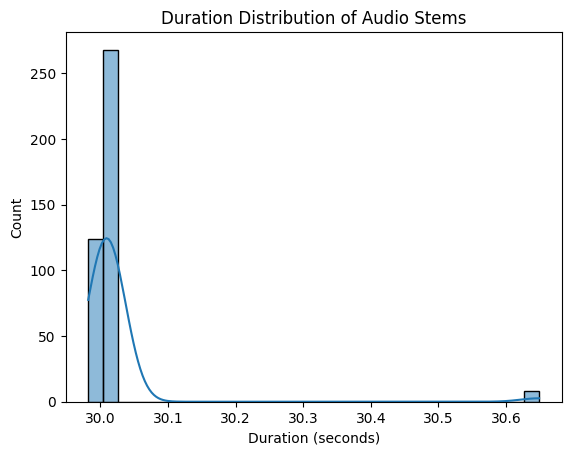

In [13]:
# Duration Distribution
sns.histplot(audio_stats_df['duration'], bins=30, kde=True)
plt.title("Duration Distribution of Audio Stems")
plt.xlabel("Duration (seconds)")
plt.show()

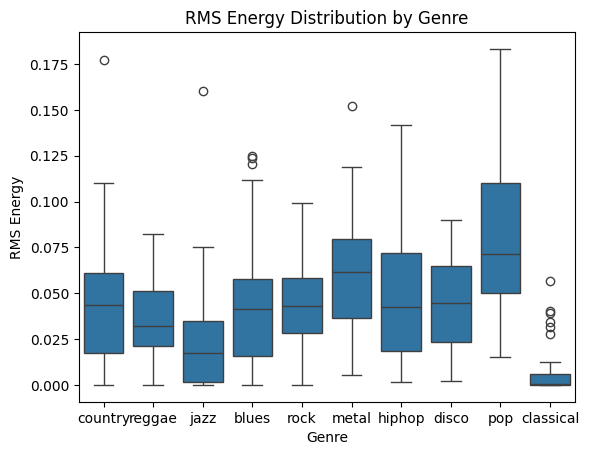

In [14]:
# RMS by Genre
sns.boxplot(x='genre', y='rms', data=audio_stats_df)
plt.title("RMS Energy Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("RMS Energy")
plt.show()

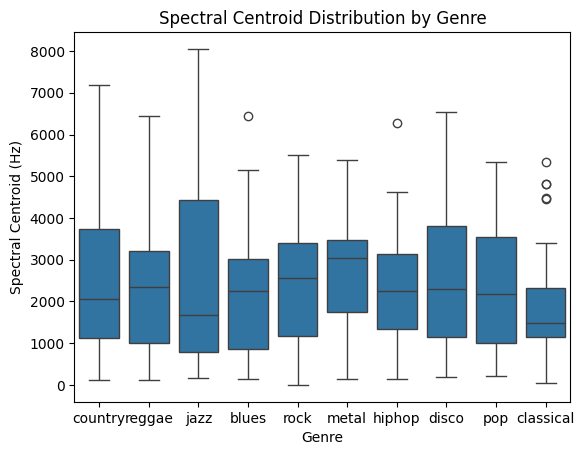

In [15]:
# spectral centroid by genre
sns.boxplot(x='genre', y='spectral_centroid', data=audio_stats_df)
plt.title("Spectral Centroid Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Spectral Centroid (Hz)")
plt.show()

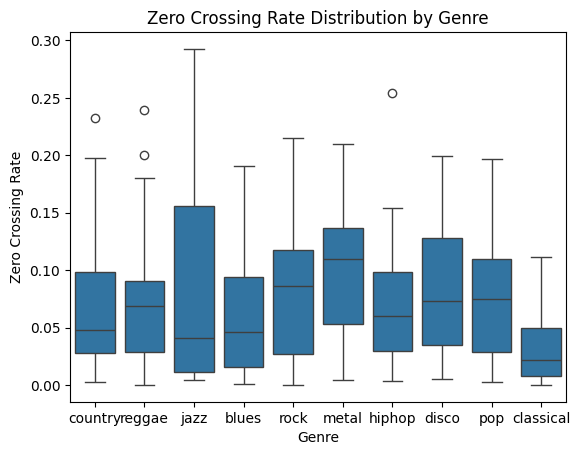

In [16]:
# zcr by genre
sns.boxplot(x='genre', y='zcr', data=audio_stats_df)
plt.title("Zero Crossing Rate Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Zero Crossing Rate")
plt.show()

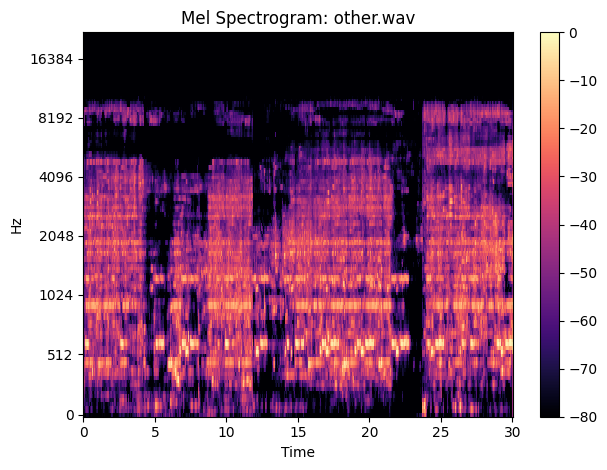

In [17]:
# Helper function to plot mel spectrogram for a given audio file
def plot_mel_spectrogram(file_path):
    y, sr = librosa.load(file_path, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr)
    S_db = librosa.power_to_db(S, ref=np.max)

    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title(f"Mel Spectrogram: {file_path.name}")
    plt.tight_layout()
    plt.show()

# Plot mel spectrogram for a random stem
random_stem = audio_stats_df.sample(1).iloc[0]
random_stem_path = GENRES_PATH / random_stem['genre'] / random_stem['song'] / random_stem['stem']
plot_mel_spectrogram(random_stem_path)

## Noise ESC-50 Data 

In [18]:
# ESC-50 Metadata
noise_metadata_path = ESC50_PATH / "meta"
noise_metadata_df = pd.read_csv(noise_metadata_path / "esc50.csv")
noise_metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  2000 non-null   object
 1   fold      2000 non-null   int64 
 2   target    2000 non-null   int64 
 3   category  2000 non-null   object
 4   esc10     2000 non-null   bool  
 5   src_file  2000 non-null   int64 
 6   take      2000 non-null   object
dtypes: bool(1), int64(3), object(3)
memory usage: 95.8+ KB


In [19]:
noise_metadata_df.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [35]:
ESC50_AUDIO_PATH = ESC50_PATH / "audio"

def analyse_noise():
    stats=[]
    
    audios=list(ESC50_AUDIO_PATH.glob("*.wav"))
    # randomly sample 100 audio files for analysis
    sampled_audios = np.random.choice(audios, size=min(100, len(audios)), replace=False)

    for file_path in tqdm(sampled_audios, desc="Analyzing Noise Files", unit="file"):
        audio_stats = extract_audio_stats(file_path)
        if audio_stats:
            audio_stats["file_name"] = file_path.name
            stats.append(audio_stats)
    return stats

noise_stats_df = pd.DataFrame(analyse_noise())

Analyzing Noise Files: 100%|██████████| 100/100 [00:09<00:00, 10.52file/s]


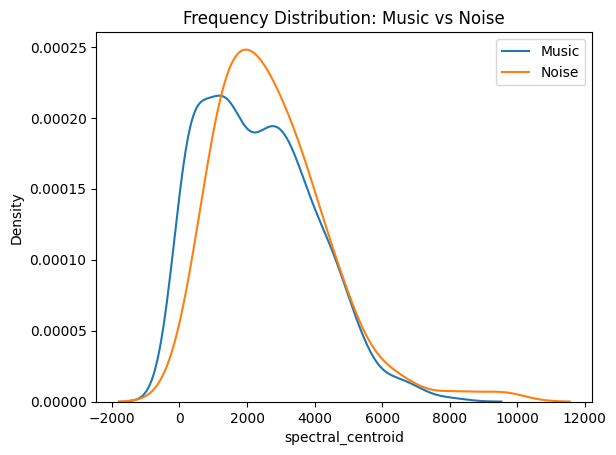

In [37]:
# Compare spectral centroid distributions between music and noise

sns.kdeplot(audio_stats_df["spectral_centroid"], label="Music")
sns.kdeplot(noise_stats_df["spectral_centroid"], label="Noise")
plt.legend()
plt.title("Frequency Distribution: Music vs Noise")
plt.show()